# Prédiction du risque de défaut de crédit - Data Tour 2025

**Auteur :** Laté LAWSON - Data Tour Afrique 2025

*Un rapport de synthese (PDF) est disponible dans `reports/` pour une lecture condensee.*

## Contexte

**Data Tour 2025**, competition panafricaine de data science 
- problème de **credit scoring**.

Objectif : à partir de l'historique de produits de crédit d'un client (17,6M lignes, 62 colonnes, 2,9M clients), prédire la probabilité qu'un prêt donné fasse défaut (`flag`).

**Pipeline :**
1. Exploration des données et de la target (`flag`) (sections 2-3)
2. Echantillonnage stratifié (section 4)
3. Feature engineering (section 5)
4. Modèle **LightGBM** (section 6)
5. Evaluation (ROC AUC), importance des variables (gain + **SHAP**) (sections 7-8)
6. Etape complémentaire sur l'historique client (section 9)
7. Conclusion (section 10)


## 1. Imports

In [1]:
import time
import json
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = "../data/raw/data.parquet"

c:\Users\latej\Desktop\Data_Tour\Default-risk-prediction-can-data-tour-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Chargement et exploration des données

Le fichier `data.parquet` est volumineux (~350 Mo, 17,6M lignes). On commence par lire uniquement
ses **metadonnees** (nombre de lignes,  nombre de colonnes, nombre de row groups) sans tout charger en mémoire.

In [2]:
pf = pq.ParquetFile(DATA_PATH)
print("Nombre de lignes   :", pf.metadata.num_rows)
print("Nombre de colonnes :", pf.metadata.num_columns)
print("Nombre de row groups:", pf.metadata.num_row_groups)

Nombre de lignes   : 17659833
Nombre de colonnes : 62
Nombre de row groups: 17


**Pourquoi passer par `pyarrow` plutôt que `pd.read_parquet(...)` directement ?** Un fichier
parquet n'est pas stocké comme un seul bloc : il est decoupé en *row groups* (ici 17, ~1M lignes
chacun). `pq.ParquetFile(...)` ouvre le fichier sans rien charger, et `read_row_group(i)` permet de
ne lire qu'un morceau à la fois. Pratique pour explorer un fichier de 350 Mo sans le charger
entièrement en mémoire a chaque fois.

In [3]:
# Aperçu d'un échantillon (1 row group ~ 1M lignes) pour l'EDA rapide
sample = pf.read_row_group(0).to_pandas()
sample.head(3)

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,...,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,flag
0,1678548,3,8,7,17,16,9,1,9,2,3,0,2,2,6,...,0,0,0,1,0,0,0,1,1,3,2,1,0,0,0
1,2834188,11,3,2,0,7,14,8,2,5,1,0,2,13,6,...,0,0,0,1,0,0,0,1,1,2,4,1,0,0,0
2,811902,11,9,6,11,13,14,8,2,5,1,0,2,11,6,...,3,3,3,4,3,3,3,4,1,2,4,1,0,0,0


In [4]:
# Types des colonnes
print(sample.dtypes.value_counts())

int8     61
int32     1
Name: count, dtype: int64


In [5]:
all_hashes = [] # pour vérifier les doublons
total_na = 0
for i in range(pf.metadata.num_row_groups):
    chunk = pf.read_row_group(i).to_pandas()
    total_na += chunk.isna().sum().sum()
    # hash_pandas_object resume chaque ligne (62 colonnes) en un seul entier :
    # deux lignes identiques donnent le même hash, deux lignes différentes donnent
    # des hash différents. Permet de comparer les lignes entre
    # row groups sans jamais charger les 17,6M lignes dans un seul DataFrame.
    all_hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy())

all_hashes = np.concatenate(all_hashes)  # un entier par ligne, 17,6M au total

# np.unique(..., return_counts=True) compte les occurrences de chaque hash.
# counts > 1 => plusieurs lignes (potentiellement dans des row groups differents)
# ont exactement le meme contenu => doublon.
_, counts = np.unique(all_hashes, return_counts=True)

print("Valeurs manquantes (17,6M lignes) :", total_na)
print("Lignes en doublon :", int((counts - 1)[counts > 1].sum()))

Valeurs manquantes (17,6M lignes) : 0
Lignes en doublon : 0


**Pas de valeur manquante, pas de doublon**, données propres.

## 3. Analyse de la target

On relit les 17 row groups en entier, mais uniquement les colonnes `id` et `flag` (2 sur 62).

In [6]:
parts = [pf.read_row_group(i, columns=["id", "flag"]).to_pandas()
         for i in range(pf.metadata.num_row_groups)]
id_flag_all = pd.concat(parts, ignore_index=True)
print("Lignes totales :", len(id_flag_all))

id_flag = id_flag_all.groupby("id")["flag"].first()
print("Clients uniques :", id_flag.shape[0])
print(id_flag.value_counts(normalize=True))

# Le flag est-il le même pour toutes les lignes (tous les prêts) d'un même client ?
nunique_flag_per_client = id_flag_all.groupby("id")["flag"].nunique()
print("Clients avec un flag différent entre leurs lignes :", (nunique_flag_per_client > 1).sum())

Lignes totales : 17659833
Clients uniques : 2892602
flag
0    0.965014
1    0.034986
Name: proportion, dtype: float64
Clients avec un flag différent entre leurs lignes : 0


**Remarques** :

- Données **déséquilibrées** (~3,5% de defauts) => décision : géré via `scale_pos_weight` dans les modèles. 
- `flag` est **identique pour toutes les lignes d'un même client** => la target est en réalite définie au niveau du client, pas du prêt. 

## 4. Echantillonnage stratifié

Le jeu complet (17,6M lignes / 2,9M clients) est trop volumineux. Pour accelérer l'entrainement, on construit un **échantillon stratifié par client** (jamais par ligne, pour ne pas couper l'historique d'un client) : un sous-echantillon de clients en défaut + un sous-echantillon de clients sans defaut, dans un ratio moins extrême (moins déséquilibré) que le ratio naturel.

In [7]:
pos_series = id_flag[id_flag == 1]
neg_series = id_flag[id_flag == 0]

pos_sample = pos_series.sample(n=50_000, random_state=RANDOM_STATE)
neg_sample = neg_series.sample(n=100_000, random_state=RANDOM_STATE)
sampled_ids = pd.Index(pos_sample.index).append(pd.Index(neg_sample.index))

print("Clients échantillonnés :", len(sampled_ids), "-> taux de défaut dans l'échantillon :",
      round(len(pos_sample) / len(sampled_ids), 3))

Clients échantillonnés : 150000 -> taux de défaut dans l'échantillon : 0.333


In [8]:
id_set = set(sampled_ids.tolist())
parts = []
for i in range(pf.metadata.num_row_groups):
    chunk = pf.read_row_group(i).to_pandas()
    parts.append(chunk[chunk["id"].isin(id_set)])
df = pd.concat(parts, ignore_index=True)
print("Lignes extraites :", df.shape)

Lignes extraites : (903011, 62)


## 5. Feature engineering

Trois familles de variables, particulièrement efficaces pour ce type de scoring credit :

1. **Historique de paiement** (`enc_paym_0..24`) : moyenne, ecart-type, pire statut, retards,
   tendance recente vs ancienne, plus longue sequence de retard.
2. **Ratios financiers** : encours/plafond, impayes/plafond, prochaine echeance/encours,
   depassement/plafond - plus parlants pour un modele que des montants bruts.
3. **Agregats client** (`groupby("id")`) : moyenne/max/ecart-type des principales variables sur
   l'historique du client + nombre de produits détenus.

On exclut 3 colonnes **à risque de fuite** (`pre_fterm`, `pre_till_fclose`, `fclose_flag`) :
connues seulement à la clôture d'un prêt, donc logiquement indisponibles au moment de la
prédiction.

### Historique de paiement

In [9]:
paym_cols = [f"enc_paym_{i}" for i in range(25)]
paym = df[paym_cols].to_numpy(dtype=np.int16)

feats = {}
feats["paym_mean"] = paym.mean(axis=1).astype(np.float32)
feats["paym_std"] = paym.std(axis=1).astype(np.float32)
feats["paym_max"] = paym.max(axis=1).astype(np.int8)
feats["paym_sum_late"] = (paym > 0).sum(axis=1).astype(np.int8)
feats["paym_trend"] = (paym[:, :6].mean(axis=1) - paym[:, 6:].mean(axis=1)).astype(np.float32)

# Plus longue séquence consécutive de retard
late = (paym > 0).astype(np.int32)
run = np.zeros_like(late)
run[:, 0] = late[:, 0]
for j in range(1, late.shape[1]):
    run[:, j] = np.where(late[:, j] == 1, run[:, j - 1] + 1, 0)
feats["paym_longest_late_streak"] = run.max(axis=1).astype(np.int8)
print("Features de paiement calculees :", list(feats.keys()))

Features de paiement calculees : ['paym_mean', 'paym_std', 'paym_max', 'paym_sum_late', 'paym_trend', 'paym_longest_late_streak']


### Ratios financiers

In [10]:
def safe_div(a, b):
    a = a.to_numpy(dtype=np.float32)
    b = b.to_numpy(dtype=np.float32)
    out = np.zeros_like(a)
    mask = b != 0
    out[mask] = a[mask] / b[mask]
    return out

feats["ratio_outstanding_limit"] = safe_div(df["pre_loans_outstanding"], df["pre_loans_credit_limit"])
feats["ratio_overdue_limit"] = safe_div(df["pre_loans_total_overdue"], df["pre_loans_credit_limit"])
feats["ratio_nextpay_outstanding"] = safe_div(df["pre_loans_next_pay_summ"], df["pre_loans_outstanding"])
feats["ratio_over2limit"] = safe_div(df["pre_over2limit"], df["pre_loans_credit_limit"])

feat_df = pd.DataFrame(feats, index=df.index)
df = pd.concat([df, feat_df], axis=1)
df = df.drop(columns=["pre_fterm", "pre_till_fclose", "fclose_flag"])
print("Shape apres feature engineering ligne :", df.shape)

Shape apres feature engineering ligne : (903011, 69)


### Agregats client

In [11]:
agg_cols = ["pre_loans_outstanding", "pre_loans_total_overdue", "pre_loans_credit_limit",
            "pre_loans_max_overdue_sum", "paym_mean", "paym_sum_late"]

client_agg = df.groupby("id")[agg_cols].agg(["mean", "max", "std"]).fillna(0).astype(np.float32)
client_agg.columns = ["client_" + "_".join(c) for c in client_agg.columns]
client_agg["client_num_products"] = df.groupby("id").size().astype(np.int16)

df = df.merge(client_agg, on="id", how="left")
print("Shape final (avec agregats client) :", df.shape)

Shape final (avec agregats client) : (903011, 88)


## 6. Modèle : LightGBM 
**LightGBM** : choix répandu pour ce type de problème, déséquilibre géré via `scale_pos_weight`.

Hyperparamètres par défaut : aucun réglage arbitraire, seulement scale_pos_weight et l'early stopping.

### Split train / validation
**Piege frequent** sur ce type de donnees : valider avec un split **au niveau des lignes** (par
exemple un `train_test_split` classique stratifie sur `flag`). Un meme client peut apparaitre dans
plusieurs lignes tres similaires - s'il se retrouve en train ET en validation, le modele peut
"reconnaitre" ce client plutot que d'apprendre un vrai signal de risque (rappel section 3 : `flag`
est identique pour toutes les lignes d'un meme client). On verifie d'abord ce piege concretement,
puis on construit le split correct.

#### Split stratifié sur flag

In [12]:
train1, valid1 = train_test_split(
    df, test_size=0.2, stratify=df["flag"], random_state=RANDOM_STATE
)

ids_train1 = set(train1["id"])
ids_valid1 = set(valid1["id"])
overlap = ids_train1 & ids_valid1
print("Clients présents à la fois en train et valid :", len(overlap),
      "/", df["id"].nunique(), "clients uniques")
print("Lignes concernées par un client partagé entre train et valid :",
      df["id"].isin(overlap).sum(), "/", len(df))

Clients présents à la fois en train et valid : 90254 / 150000 clients uniques
Lignes concernées par un client partagé entre train et valid : 711232 / 903011


#### Modèle avec split stratifié sur flag

In [13]:
drop_cols = ["id", "flag"]
feature_cols_1 = [c for c in train1.columns if c not in drop_cols]
X_train1, y_train1 = train1[feature_cols_1], train1["flag"]
X_valid1, y_valid1 = valid1[feature_cols_1], valid1["flag"]
scale_pos_weight1 = (y_train1 == 0).sum() / (y_train1 == 1).sum()

dtrain1 = lgb.Dataset(X_train1, label=y_train1, free_raw_data=False)
dvalid1 = lgb.Dataset(X_valid1, label=y_valid1, reference=dtrain1, free_raw_data=False)
params1 = dict(objective="binary", metric="auc", scale_pos_weight=scale_pos_weight1,
                n_jobs=-1, seed=RANDOM_STATE, verbose=-1)

model1 = lgb.train(params1, dtrain1, num_boost_round=150, valid_sets=[dvalid1],
                           valid_names=["valid"], callbacks=[lgb.early_stopping(20, verbose=False)])
pred1 = model1.predict(X_valid1)
print("AUC (split stratifié par flag) :", round(roc_auc_score(y_valid1, pred1), 4))


AUC (split stratifié par flag) : 0.7247


On obtient : **AUC = 0.7247**.

Sur ce split, **90 254 clients (60%) et 711 232 lignes (79%)** sont partagés entre train et validation. Le modèle "reconnait" une partie des clients de validation via leurs autres lignes vues en entrainement => ce n'est donc pas un vrai signal de risque généralisable à de nouveaux clients (rappel section 3 : `flag`
est identique pour toutes les lignes d'un même client).

#### Split groupé par client et stratifié sur flag

Split **groupé par client** (chaque client va entièrement en train ou en validation,
jamais les deux) **et stratifié par flag** (le même taux de défaut des deux côtés, calculé
séparement pour les clients en défaut et sans défaut).

In [14]:
rng = np.random.RandomState(RANDOM_STATE)
client_flag = df.groupby("id")["flag"].first()
pos_ids = client_flag[client_flag == 1].index.to_numpy().copy()
neg_ids = client_flag[client_flag == 0].index.to_numpy().copy()
rng.shuffle(pos_ids)
rng.shuffle(neg_ids)

n_valid_pos = int(len(pos_ids) * 0.2)
n_valid_neg = int(len(neg_ids) * 0.2)
valid_ids = set(pos_ids[:n_valid_pos]) | set(neg_ids[:n_valid_neg])

is_valid = df["id"].isin(valid_ids)
train_df = df[~is_valid].reset_index(drop=True)
valid_df = df[is_valid].reset_index(drop=True)

print("Train :", train_df.shape, "-> taux de defaut :", round(train_df["flag"].mean(), 3))
print("Valid :", valid_df.shape, "-> taux de defaut :", round(valid_df["flag"].mean(), 3))

Train : (721965, 88) -> taux de defaut : 0.323
Valid : (181046, 88) -> taux de defaut : 0.324


Aucun client partagé entre les deux ensembles.

#### Modèle avec split groupé par client et stratifié sur flag



In [15]:
drop_cols = ["id", "flag"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df["flag"]
X_valid, y_valid = valid_df[feature_cols], valid_df["flag"]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

params = dict(
    objective="binary",
    metric="auc",
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    seed=RANDOM_STATE,
    verbose=-1,
)

dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain, free_raw_data=False)

model = lgb.train(
    params, dtrain, num_boost_round=200,
    valid_sets=[dvalid], valid_names=["valid"],
    callbacks=[lgb.log_evaluation(20), lgb.early_stopping(stopping_rounds=20)],
)
print("Meilleure iteration :", model.best_iteration)

scale_pos_weight = 2.092
Training until validation scores don't improve for 20 rounds
[20]	valid's auc: 0.67218
[40]	valid's auc: 0.680483
[60]	valid's auc: 0.683727
[80]	valid's auc: 0.6845
[100]	valid's auc: 0.685159
Early stopping, best iteration is:
[87]	valid's auc: 0.685291
Meilleure iteration : 87


#### Optimisation avec Optuna

La recherche d'hyperparamètres a été testée avec Optuna : gain marginal (entre +0.002 et +0.004 d'AUC selon le nombre d'essais), pas de quoi abandonner cette version simple.

## 7. Evaluation finale et variables importantes

In [16]:
pred_train = model.predict(X_train)
pred_valid = model.predict(X_valid)

print("ROC AUC train :", round(roc_auc_score(y_train, pred_train), 4))
print("ROC AUC valid :", round(roc_auc_score(y_valid, pred_valid), 4))

ROC AUC train : 0.7206
ROC AUC valid : 0.6853


Note : `model.predict()` renvoie ici directement des probabilités (API native LightGBM),
nécessaires pour un AUC correct - contrairement a certains wrappers scikit-learn ou `.predict()`
renvoie des labels durs (0/1), ce qui fausserait fortement le score.

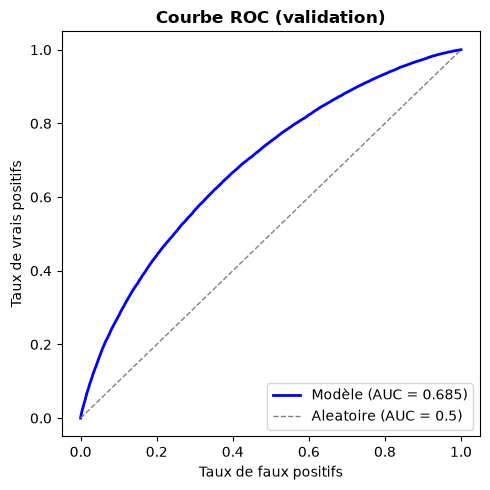

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_valid, pred_valid)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="blue", linewidth=2,
        label=f"Modèle (AUC = {roc_auc_score(y_valid, pred_valid):.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="Aleatoire (AUC = 0.5)")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbe ROC (validation)", fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

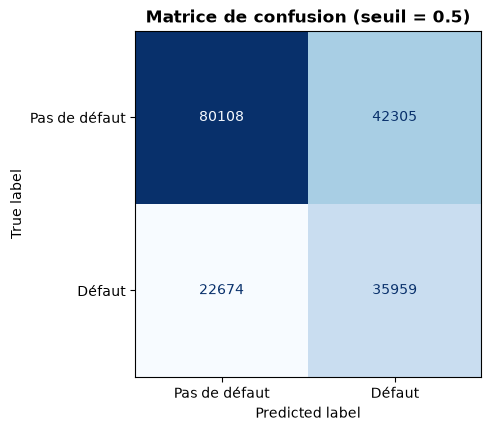

In [18]:
threshold = 0.5
pred_labels = (pred_valid >= threshold).astype(int)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_valid, pred_labels,
    display_labels=["Pas de défaut", "Défaut"],
    cmap="Blues", ax=ax, colorbar=False, values_format="d",
)
ax.set_title("Matrice de confusion (seuil = 0.5)", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
print(classification_report(y_valid, pred_labels, target_names=["Pas de defaut", "Defaut"]))


               precision    recall  f1-score   support

Pas de defaut       0.78      0.65      0.71    122413
       Defaut       0.46      0.61      0.53     58633

     accuracy                           0.64    181046
    macro avg       0.62      0.63      0.62    181046
 weighted avg       0.68      0.64      0.65    181046



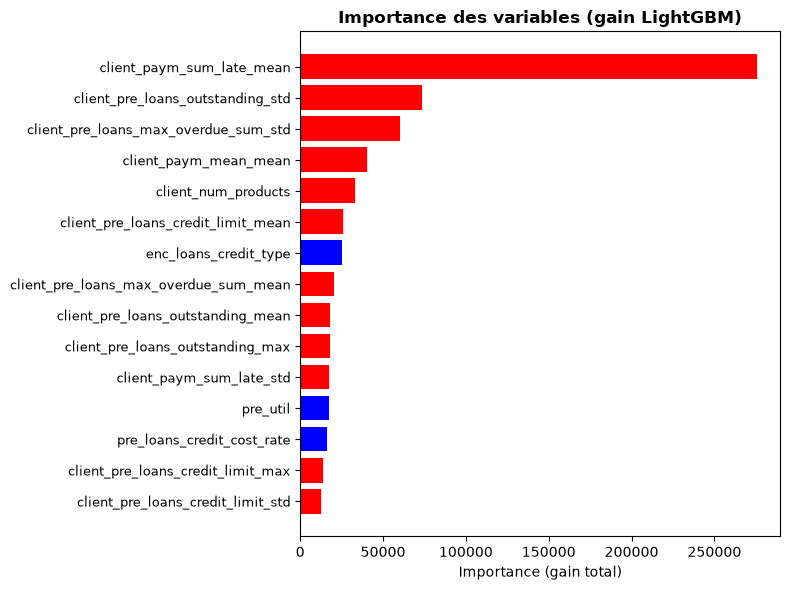

In [20]:
importance = pd.Series(
    model.feature_importance(importance_type="gain"),
    index=feature_cols
).sort_values(ascending=False)
top15 = importance.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["red" if "client" in f else "blue" for f in top15.index[::-1]]
ax.barh(range(len(top15)), top15.values[::-1], color=colors)
ax.set_yticks(range(len(top15))); ax.set_yticklabels(top15.index[::-1], fontsize=9)
ax.set_xlabel("Importance (gain total)")
ax.set_title("Importance des variables (gain LightGBM)", fontweight="bold")
fig.tight_layout()
plt.show()

Les **agregats au niveau client** dominent largement (11 des 15 premieres) : l'historique
complet du client porte plus d'information que les seules caractéristiques du prêt évalue.

## 8. Interpretabilite du modèle avec SHAP

L'importance par gain (section 7) est une moyenne globale : elle ne dit pas **dans quel sens** une
variable pousse la prédiction, ni si son effet est constant. **SHAP** donne, pour chaque prédiction,
une contribution signée par variable (positive = pousse vers le défaut). On utilise ici la
librairie `shap` (`TreeExplainer`).

In [21]:
explainer = shap.TreeExplainer(model)
sample = X_valid.sample(n=20_000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top15 = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False).head(15)
top15

c:\Users\latej\Desktop\Data_Tour\Default-risk-prediction-can-data-tour-\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


client_paym_sum_late_mean                0.372480
client_pre_loans_outstanding_std         0.154248
client_pre_loans_max_overdue_sum_std     0.131842
client_paym_mean_mean                    0.087826
client_pre_loans_credit_limit_max        0.072200
pre_loans_credit_cost_rate               0.065286
enc_loans_credit_type                    0.043436
client_pre_loans_outstanding_max         0.042816
client_pre_loans_max_overdue_sum_mean    0.042227
is_zero_loans530                         0.041573
client_pre_loans_credit_limit_mean       0.038210
rn                                       0.035779
client_paym_sum_late_max                 0.035604
client_num_products                      0.034755
pre_util                                 0.034154
dtype: float64

Le classement SHAP **confirme** celui du gain (agregats client en tete) => bon signe de
coherence. L'interet de SHAP est surtout dans le graphique suivant : la **distribution** et le
**sens** de l'effet de chaque variable.

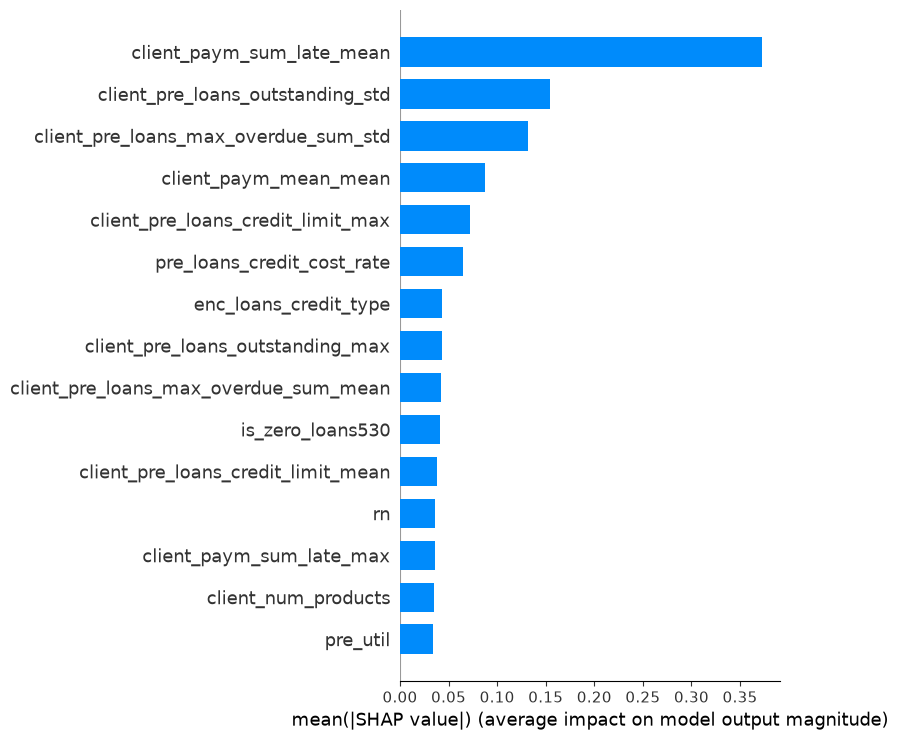

In [22]:
shap.summary_plot(shap_values, sample, plot_type="bar", max_display=15, show=True)

**Beeswarm plot** : chaque point est une ligne de validation, sa position horizontale est sa
contribution SHAP, et sa couleur représente le niveau de la variable pour cette ligne.

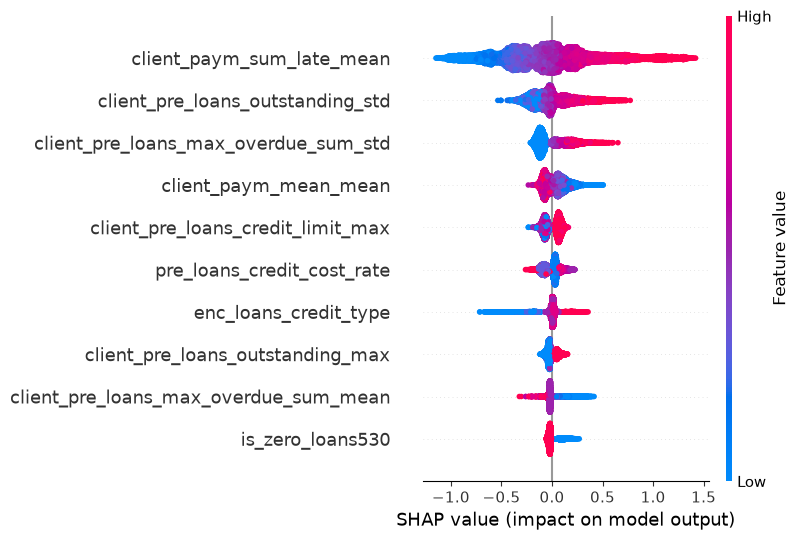

In [23]:
shap.summary_plot(shap_values, sample, max_display=10, show=True)

**Lecture** : pour `client_paym_sum_late_mean`, les points rouges (valeur elevée) sont
majoritairement à droite (pousse vers le défaut) et les bleus à gauche. 

Pour `client_pre_loans_credit_limit_max`, l'effet est plus mélange. 

Ce niveau de detail n'est pas visible avec la seule importance par gain.

## 9. Etape complémentaire : pondérer par l'historique du client (`id`)

**Objectif** : montrer, comment exploiter le fait qu'un client peut avoir **plusieurs prêts** dans les données. Si l'issue de l'un est connue, c'est un signal fort sur les autres (pratique courante en scoring). Plutôt qu'un post-traitement fragile (remplacer la prediction par le comportement majoritaire connu du client), on integre l'information comme **variable du modèle**, via un encodage **leave-one-out**.

**Pourquoi leave-one-out ?** Calculer `moyenne(flag)` par `id` **en incluant la ligne elle-même**
est une fuite de cible directe (la ligne "voit" sa propre étiquette). La version leave-one-out
calcule la moyenne des `flag` des **autres** prêts du même client, en excluant la ligne
courante.

**A distinguer du piège de la section 6** : ici l'information sur l'historique du client est
ajoutée de maniere **explicite et mesurée** (une variable, dont la contribution est decomposée
ci-dessous) - pas via une fuite accidentelle liée à un mauvais split.

In [24]:
def add_client_history_feature(df):
    grp = df.groupby("id")["flag"]
    somme = grp.transform("sum")
    compte = grp.transform("count")
    # Moyenne du flag des AUTRES lignes du même client (on retire la ligne courante)
    loo = (somme - df["flag"]) / (compte - 1)
    loo = loo.fillna(df["flag"].mean())  # pas d'autre prêt connu -> valeur neutre (moyenne globale)
    df["client_flag_rate_loo"] = loo.astype(np.float32)
    df["client_has_history"] = (compte > 1).astype(np.int8)
    return df

train_df = add_client_history_feature(train_df)
valid_df = add_client_history_feature(valid_df)

print("Part des lignes train avec >= 1 autre pret connu :", round(train_df["client_has_history"].mean(), 3))
print("Part des lignes valid avec >= 1 autre pret connu :", round(valid_df["client_has_history"].mean(), 3))


Part des lignes train avec >= 1 autre pret connu : 0.979
Part des lignes valid avec >= 1 autre pret connu : 0.979


97,9% des lignes ont un autre prêt connu dans le même sous-ensemble : la variable est donc
informative presque partout (neutre pour les rares clients à un seul prêt). On réentraine le même
LightGBM en ajoutant ces deux colonnes.

In [25]:
feature_cols_v2 = [c for c in train_df.columns if c not in drop_cols]
X_train2, X_valid2 = train_df[feature_cols_v2], valid_df[feature_cols_v2]

dtrain2 = lgb.Dataset(X_train2, label=y_train, free_raw_data=False)
dvalid2 = lgb.Dataset(X_valid2, label=y_valid, reference=dtrain2, free_raw_data=False)

model2 = lgb.train(
    params, dtrain2, num_boost_round=40,
    valid_sets=[dvalid2], valid_names=["valid"],
    callbacks=[lgb.log_evaluation(10)],
)


[10]	valid's auc: 0.999841
[20]	valid's auc: 0.999846
[30]	valid's auc: 0.99985
[40]	valid's auc: 0.999852


**Le ROC AUC passe de 0.685 a ~0.9999.** Un saut aussi brutal doit alerter plutôt que réjouir. Décomposons avant de le présenter comme un succes.

In [26]:
pred2 = model2.predict(X_valid2)
mask_hist = valid_df["client_has_history"] == 1
mask_new = ~mask_hist

print("AUC global                       :", round(roc_auc_score(y_valid, pred2), 4))
print("AUC sur clients AVEC historique   :", round(roc_auc_score(valid_df.loc[mask_hist, "flag"], pred2[mask_hist.to_numpy()]), 4),
      f"({mask_hist.mean():.1%} des lignes)")
print("AUC sur clients SANS historique   :", round(roc_auc_score(valid_df.loc[mask_new, "flag"], pred2[mask_new.to_numpy()]), 4),
      f"({mask_new.mean():.1%} des lignes)")


AUC global                       : 0.9999
AUC sur clients AVEC historique   : 1.0 (97.9% des lignes)
AUC sur clients SANS historique   : 0.6805 (2.1% des lignes)


### Explication du résultat

- Clients **avec historique** (97,9%) : AUC **exactement 1.0** - pas un exploit de modélisation.
  `flag` étant identique pour toutes les lignes d'un client (section 3), `client_flag_rate_loo`
  **recopie exactement** l'étiquette à partir d'un autre prêt du même client - rien à "apprendre".
- Clients **sans historique** (2,1%) : AUC **0.68**, quasi identique au modèle de base (0.685) -
  c'est cette valeur, pas 0.9999, qui reflète la vraie capacite du modèle sur un nouveau client.

C'est le mème type de mécanisme que le piège du split naif (section 6), mais intégré ici de façon
explicite et mesurée plutôt que par accident.

**Légitime ou trompeur ?** Légitime dans un contexte réel (un etablissement connait l'historique
de ses clients existants) pour un **client récurrent**. Trompeur si on présente le score global
(0.9999) sans le décomposer - cela masque la vraie capacite du modele sur un **nouveau client**,
le cas d'usage le plus important en pratique.

**Recommandation retenue** : le modele simple (section 7, AUC ~0.685) reste le resultat principal.
Cette section est presentée, décomposée, pour documenter la technique sans gonfler
artificiellement le score.

## 10. Conclusion

| Version | ROC AUC (valid) | Ce qu'elle mesure |
|---|---|---|
| Split naif (contre-exemple, section 6) | 0.7247 (gonflée) | Fuite via des clients partagés entre train et validation - ne reflete pas la vraie capacite du modèle. |
| Modèle simple, split groupe (section 6) | **~0.685** | Capacite réelle à évaluer un risque de crédit à partir des caracteristiques d'un prêt - le cas d'usage le plus utile (nouveau client). |
| + historique client LOO (section 9) | **~0.9999** (1.0 sur 97,9% des lignes, 0.68 sur les 2,1% sans historique) | Capacite à *retrouver* le flag via un autre prêt du même client, quand l'info existe déja. |

On retient le **modele simple avec split groupe (~0.685)** comme resultat principal : score généralisable (pas de fuite de cible ni de client, split stratifié).
Details complets et mise en perspective : voir le rapport PDF (`reports/`).

**Recherche d'hyperparametres (Optuna)** : testée séparément (recherche resserrée puis plus large,
jusqu'a 60 essais). Gain observé : entre +0.002 et +0.004 d'AUC selon le nombre
d'essais. Par préférence de rapidité d'excécution, l'optimisation n'a pas été retenue, mais documenté comme piste testée plutôt qu'ignorée.

**Pistes d'amelioration (non retenues ici pour rester simple)** : entrainement sur le jeu complet,
`GroupKFold` a K plis, **ensembling/stacking** (LightGBM + CatBoost + méta-modèle) - gain généralement modeste dans ce type de probleme mais non testé ici, et en production exposer séparément les métriques clients connus / nouveaux clients plutôt qu'un score global.
